# **Causal Transformer Model**
### - Pretrained FastText English Language Word Vectors (cc.en.300.vec)
### - relative positions with position embeddings

## **Import Libraries**

In [151]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from gensim.models import KeyedVectors
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score, auc, roc_auc_score, roc_curve

## **Load the Dataset**

In [152]:
# Loading the data
X_train = pd.read_csv("X_train.csv")["Final_Cleaned_Tweet"]
X_val = pd.read_csv("X_val.csv")["Final_Cleaned_Tweet"]
X_test = pd.read_csv("X_test.csv")["Final_Cleaned_Tweet"]

y_train = pd.read_csv("y_train.csv")["Sentiment"]
y_val = pd.read_csv("y_val.csv")["Sentiment"]
y_test = pd.read_csv("y_test.csv")["Sentiment"]

### Data Overview

In [153]:
# X_train data overview
print("X_train Shape : ", X_train.shape)
print(X_train.describe())
X_train.head(5)

X_train Shape :  (183861,)
count            183781
unique           161290
top       freedomconvoy
freq               1150
Name: Final_Cleaned_Tweet, dtype: object


0    ottawa police chief swears repeat last winter ...
1    paris police ban french freedom convoy demonst...
2    mandate o'toole step u hop leader idiotic rhet...
3    freedom convoy protest ottawa police presence ...
4    freedomconvoy preemptive so press conference f...
Name: Final_Cleaned_Tweet, dtype: object

In [154]:
# Corresponding y_train data overview
print("y_train Shape : ", y_train.shape)
print(y_train.describe())
y_train.head(5)

y_train Shape :  (183861,)
count       183861
unique           3
top       negative
freq         61287
Name: Sentiment, dtype: object


0    negative
1    negative
2    negative
3    negative
4    negative
Name: Sentiment, dtype: object

## **Data Preprocessing**

### **Label Encoding**

In [155]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

### **Load the Pretrained Word Vector file from FastText**

In [156]:
# Load pretrained fastText embeddings and build vocab-to-index mapping
ft_model = KeyedVectors.load_word2vec_format("cc.en.300.vec", limit=10000)
vocab = list(ft_model.key_to_index.keys())
token_to_idx = {word: idx + 2 for idx, word in enumerate(vocab)}  # 0=PAD, 1=OOV

# Create embedding matrix
embedding_dim = 300
embedding_matrix = np.zeros((len(token_to_idx) + 2, embedding_dim))
for word, i in token_to_idx.items():
    embedding_matrix[i] = ft_model[word]

### **Tokenization**

In [157]:
# Tokenizer function
def tokenize_texts(texts, token_to_idx, max_len=50):
    tokenized = []
    for text in texts:
        tokens = str(text).lower().split()
        ids = [token_to_idx.get(token, 1) for token in tokens]  # 1 = OOV token
        tokenized.append(ids[:max_len] + [0] * (max_len - len(ids)))  # 0 = PAD token
    return np.array(tokenized)

In [158]:
# Tokenizing the dataset
MAX_LEN = 50
X_train_tok = tokenize_texts(X_train, token_to_idx, max_len=MAX_LEN)
X_val_tok = tokenize_texts(X_val, token_to_idx, max_len=MAX_LEN)
X_test_tok = tokenize_texts(X_test, token_to_idx, max_len=MAX_LEN)

## **Model Building**

### Relative Position Embeddings Implementation

In [159]:
# Relative Position Embedding
class RelativePositionEmbedding(layers.Layer):
    def __init__(self, max_len, depth):
        super().__init__()
        self.rel_embeddings = self.add_weight(
            shape=(2 * max_len - 1, depth), initializer="random_normal", trainable=True
        )
        self.max_len = max_len

    def call(self, qlen, klen):
        range_vec = tf.range(klen)
        distance_mat = range_vec[None, :] - range_vec[:, None]
        clipped = tf.clip_by_value(distance_mat + self.max_len - 1, 0, 2 * self.max_len - 2)
        return tf.gather(self.rel_embeddings, clipped)

In [160]:
# Padding mask creation function
def create_padding_mask(x, pad_token=0):
    mask = tf.cast(tf.math.equal(x, pad_token), tf.float32)  # 1 for pad tokens
    return mask[:, tf.newaxis, tf.newaxis, :]  # (batch, 1, 1, seq_len)

def create_causal_mask(seq_len):
    return tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)  # (seq_len, seq_len)

def combine_masks(padding_mask, causal_mask):
    causal_mask = causal_mask[tf.newaxis, tf.newaxis, :, :]  # (1,1,seq_len,seq_len)
    combined = tf.minimum(padding_mask, causal_mask)
    return combined  # (batch, 1, seq_len, seq_len)

### Transformer Block with Causal Attention Mask Implementation

In [161]:
# Define the Transformer Block with Relative Causal Attention
class CausalTransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, max_len):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.max_len = max_len
        self.head_dim = embed_dim // num_heads

        self.q_proj = layers.Dense(embed_dim)
        self.k_proj = layers.Dense(embed_dim)
        self.v_proj = layers.Dense(embed_dim)
        self.out_proj = layers.Dense(embed_dim)

        self.rel_pos_emb = RelativePositionEmbedding(max_len, self.head_dim)

        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(0.4)
        self.dropout2 = layers.Dropout(0.4)

    def call(self, inputs, tokens=None, training=None):
        batch_size, seq_len, _ = tf.shape(inputs)[0], tf.shape(inputs)[1], tf.shape(inputs)[2]

        q = self.q_proj(inputs)
        k = self.k_proj(inputs)
        v = self.v_proj(inputs)

        q = tf.reshape(q, (batch_size, seq_len, self.num_heads, self.head_dim))
        k = tf.reshape(k, (batch_size, seq_len, self.num_heads, self.head_dim))
        v = tf.reshape(v, (batch_size, seq_len, self.num_heads, self.head_dim))

        q = tf.transpose(q, perm=[0, 2, 1, 3])  # (B, H, T, D)
        k = tf.transpose(k, perm=[0, 2, 1, 3])
        v = tf.transpose(v, perm=[0, 2, 1, 3])

        rel_pos = self.rel_pos_emb(seq_len, seq_len)  # (T, T, D)
        rel_pos = tf.transpose(rel_pos, [2, 0, 1])  # (D, T, T)

        attn_logits = tf.einsum('bhqd,bhkd->bhqk', q, k)
        rel_logits = tf.einsum('bhqd,dqk->bhqk', q, rel_pos)
        attn_logits += rel_logits

        causal_mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
        causal_mask = tf.reshape(causal_mask, (1, 1, seq_len, seq_len))
        attn_logits = tf.where(causal_mask == 0, -1e9, attn_logits)

        attention_weights = tf.nn.softmax(attn_logits, axis=-1)
        attn_output = tf.matmul(attention_weights, v)  # (B, H, T, D)
        attn_output = tf.transpose(attn_output, perm=[0, 2, 1, 3])
        attn_output = tf.reshape(attn_output, (batch_size, seq_len, self.embed_dim))

        out1 = self.layernorm1(inputs + self.dropout1(self.out_proj(attn_output), training=training))
        ffn_output = self.ffn(out1)
        return self.layernorm2(out1 + self.dropout2(ffn_output, training=training))

### Function to Build the Model with all the Layers

In [173]:
def build_model(max_len, vocab_size, embedding_matrix, num_classes):
    inputs = keras.Input(shape=(max_len,), dtype=tf.int32)  # token IDs input
    x = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_matrix.shape[1],
        weights=[embedding_matrix],
        trainable=False,
        mask_zero=False,
    )(inputs)
    # Pass both embeddings and tokens to transformer block for mask creation
    x = CausalTransformerBlock(embed_dim=embedding_matrix.shape[1], num_heads=3, ff_dim=512, max_len=max_len)(x, inputs)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs)
    return model

### **Build the Model**

In [174]:
model = build_model(
    max_len=MAX_LEN,
    vocab_size=embedding_matrix.shape[0],
    embedding_matrix=embedding_matrix,
    num_classes=len(le.classes_)
)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_40 (InputLayer)   │ (None, 50)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_13 (Embedding)      │ (None, 50, 300)           │       3,000,600 │ input_layer_40[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ causal_transformer_block_22   │ (None, 50, 300)           │         680,312 │ embedding_13[0][0],        │
│ (CausalTransformerBlock)      │                           │                 │ input_layer_40[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d_18   │ (None, 300)               │               0 │ causal_transformer_block_… │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_86 (Dropout)          │ (None, 300)               │               0 │ global_average_pooling1d_… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_91 (Dense)              │ (None, 3)                 │             903 │ dropout_86[0][0]           │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 3,681,815 (14.05 MB)

 Trainable params: 681,215 (2.60 MB)

 Non-trainable params: 3,000,600 (11.45 MB)

### Define callbacks

In [175]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
]

### **Train the Model**

In [177]:
model.fit(
    X_train_tok,
    y_train_enc,
    validation_data=(X_val_tok, y_val_enc),
    batch_size=64,
    epochs=8,
    callbacks=callbacks
)

Epoch 1/8
2873/2873 ━━━━━━━━━━━━━━━━━━━━ 234s 81ms/step - accuracy: 0.6338 - loss: 0.8122 - val_accuracy: 0.6549 - val_loss: 0.7927
Epoch 2/8
2873/2873 ━━━━━━━━━━━━━━━━━━━━ 228s 79ms/step - accuracy: 0.6668 - loss: 0.7568 - val_accuracy: 0.6707 - val_loss: 0.7550
Epoch 3/8
2873/2873 ━━━━━━━━━━━━━━━━━━━━ 234s 82ms/step - accuracy: 0.6798 - loss: 0.7362 - val_accuracy: 0.6672 - val_loss: 0.8036
Epoch 4/8
2873/2873 ━━━━━━━━━━━━━━━━━━━━ 236s 82ms/step - accuracy: 0.6887 - loss: 0.7190 - val_accuracy: 0.6853 - val_loss: 0.7427
Epoch 5/8
2873/2873 ━━━━━━━━━━━━━━━━━━━━ 240s 83ms/step - accuracy: 0.6952 - loss: 0.7083 - val_accuracy: 0.6819 - val_loss: 0.7607
Epoch 6/8
2873/2873 ━━━━━━━━━━━━━━━━━━━━ 238s 83ms/step - accuracy: 0.6981 - loss: 0.7022 - val_accuracy: 0.6822 - val_loss: 0.7482


## **Model Evaluation**

In [178]:
# Define a helper function with all the required metrics for evaluation 
def evaluate_model_classification(model, 
                                  X_train, y_train, 
                                  X_test, y_test, 
                                  label_encoder,
                                  verbose=0):
    class_names = label_encoder.classes_

    # Accuracy
    train_loss, train_acc = model.evaluate(X_train, y_train, verbose=verbose)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=verbose)

    print(f"\nAccuracy:")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy:  {test_acc:.4f}")

    # Accuracy & Loss Curves from Training History
    if hasattr(model, 'history') and model.history:
        hist = model.history.history
        if 'accuracy' in hist and 'val_accuracy' in hist:
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))

            # Accuracy
            axes[0].plot(hist['accuracy'], label='Train Acc')
            axes[0].plot(hist['val_accuracy'], label='Val Acc')
            axes[0].set_title("Accuracy over Epochs")
            axes[0].set_xlabel("Epoch")
            axes[0].set_ylabel("Accuracy")
            axes[0].legend()
            axes[0].grid()

            # Loss
            axes[1].plot(hist['loss'], label='Train Loss')
            axes[1].plot(hist['val_loss'], label='Val Loss')
            axes[1].set_title("Loss over Epochs")
            axes[1].set_xlabel("Epoch")
            axes[1].set_ylabel("Loss")
            axes[1].legend()
            axes[1].grid()

            plt.tight_layout()
            plt.show()
    
    # Predictions
    y_train_pred = np.argmax(model.predict(X_train), axis=1)
    y_train_proba = model.predict(X_train)

    y_test_pred = np.argmax(model.predict(X_test), axis=1)
    y_test_proba = model.predict(X_test)

    # Confusion Matrix
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    cm_train = confusion_matrix(y_train, y_train_pred)
    cm_test = confusion_matrix(y_test, y_test_pred)

    ConfusionMatrixDisplay(cm_train, display_labels=class_names).plot(ax=axes[0], cmap='Blues', xticks_rotation=45, values_format='g')
    axes[0].set_title("Train Confusion Matrix")

    ConfusionMatrixDisplay(cm_test, display_labels=class_names).plot(ax=axes[1], cmap='Blues', xticks_rotation=45, values_format='g')
    axes[1].set_title("Test Confusion Matrix")

    plt.tight_layout()
    plt.show()

    # Classification Reports
    print("\nClassification Report - Train:\n")
    print(classification_report(y_train, y_train_pred, target_names=class_names))

    print("\nClassification Report - Test:\n")
    print(classification_report(y_test, y_test_pred, target_names=class_names))

    # F1 Scores Comparison Table
    def print_f1_scores(y_true_train, y_pred_train, y_true_test, y_pred_test):
        metrics = ['macro', 'micro', 'weighted']
        print(f"\nF1 Score Comparison:")
        print(f"{'Metric':<10} | {'Train':<8} | {'Test':<8}")
        print("-" * 30)
        for m in metrics:
            train_score = f1_score(y_true_train, y_pred_train, average=m)
            test_score = f1_score(y_true_test, y_pred_test, average=m)
            print(f"{m.capitalize():<10} | {train_score:.4f}  | {test_score:.4f}")

    print_f1_scores(y_train, y_train_pred, y_test, y_test_pred)

    # ROC Curve Plotting
    def plot_roc_curves(y_true, y_proba, title, ax):
        y_bin = label_binarize(y_true, classes=range(len(class_names)))
        fpr, tpr, roc_auc = {}, {}, {}

        for i in range(len(class_names)):
            fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_proba[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
            ax.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC={roc_auc[i]:.2f})")

        ax.plot([0, 1], [0, 1], 'k--')
        ax.set_title(title)
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.legend()
        ax.grid()

    # Plot side-by-side ROC curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    plot_roc_curves(y_train, y_train_proba, "ROC Curve - Train", axes[0])
    plot_roc_curves(y_test, y_test_proba, "ROC Curve - Test", axes[1])
    plt.tight_layout()
    plt.show()



Accuracy:
Train Accuracy: 0.7001
Test Accuracy:  0.7519


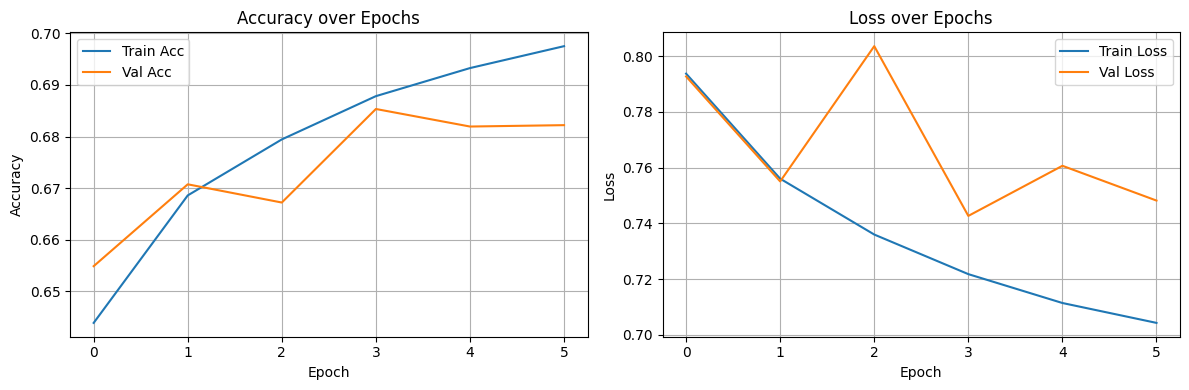

5746/5746 ━━━━━━━━━━━━━━━━━━━━ 64s 11ms/step
5746/5746 ━━━━━━━━━━━━━━━━━━━━ 68s 12ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step


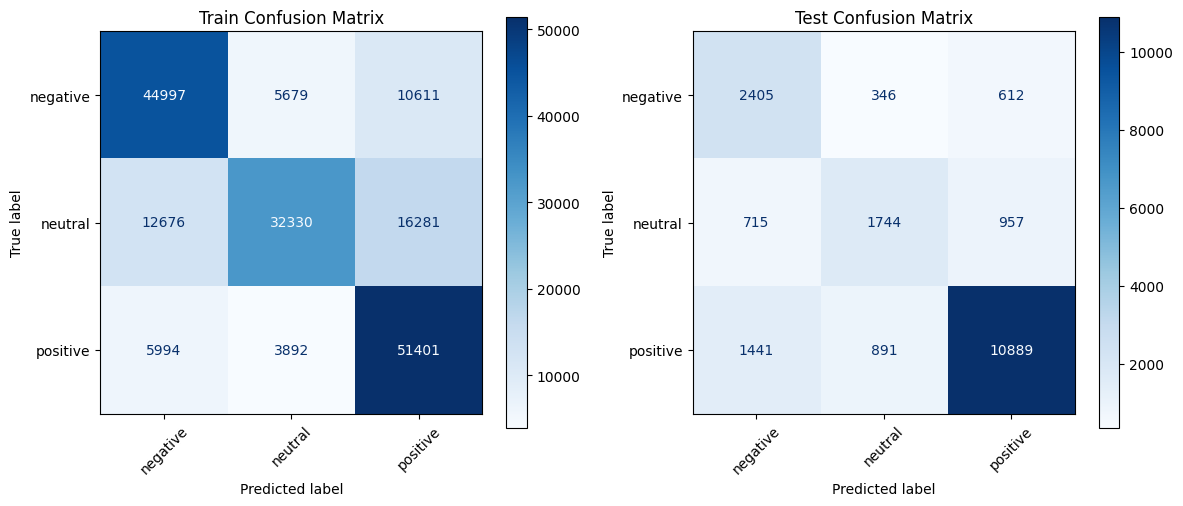


Classification Report - Train:

              precision    recall  f1-score   support

    negative       0.71      0.73      0.72     61287
     neutral       0.77      0.53      0.63     61287
    positive       0.66      0.84      0.74     61287

    accuracy                           0.70    183861
   macro avg       0.71      0.70      0.69    183861
weighted avg       0.71      0.70      0.69    183861


Classification Report - Test:

              precision    recall  f1-score   support

    negative       0.53      0.72      0.61      3363
     neutral       0.59      0.51      0.55      3416
    positive       0.87      0.82      0.85     13221

    accuracy                           0.75     20000
   macro avg       0.66      0.68      0.67     20000
weighted avg       0.77      0.75      0.76     20000


F1 Score Comparison:
Metric     | Train    | Test    
------------------------------
Macro      | 0.6944  | 0.6668
Micro      | 0.7001  | 0.7519
Weighted   | 0.6944  | 0.75

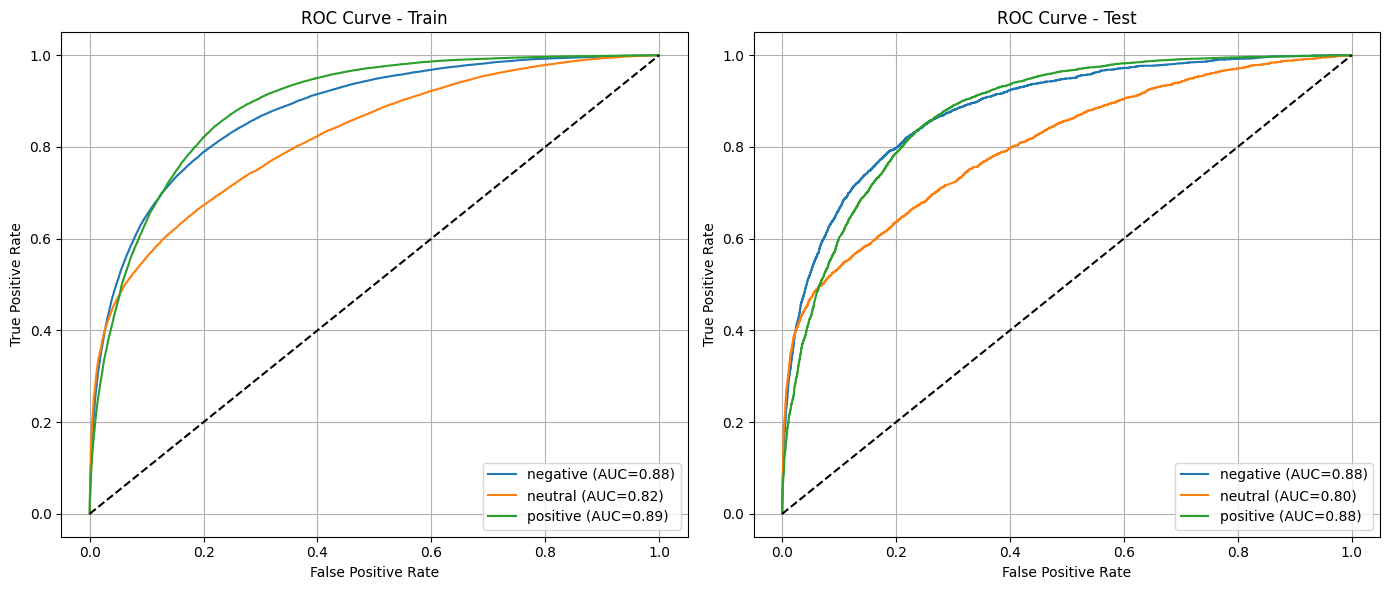

In [179]:
evaluate_model_classification(
    model=model,
    X_train=X_train_tok, y_train=y_train_enc,
    X_test=X_test_tok, y_test=y_test_enc,
    label_encoder=le
)

#### **Save the Model**

In [194]:
# Save the model
model.save("Causal_Model_1.0.h5")

## **Observations**

### Overfitting Check
- **Train Accuracy**: `70.01%`
- **Test Accuracy**: `75.19%`
- **Observation**:  
  - No signs of overfitting.
  - Validation accuracy is slightly better than training — a healthy indicator.
  - Training loss steadily decreases while validation loss stabilizes after a few fluctuations.

- **Conclusion**:  
  The model is generalizing well, with no overfitting behavior.

---

### Performance Across Classes

| Class     | Precision (Test) | Recall (Test) | F1 Score (Test) | AUC  |
|-----------|------------------|----------------|------------------|------|
| Negative  | 0.53             | 0.72           | 0.61             | 0.88 |
| Neutral   | 0.59             | 0.51           | 0.55             | 0.80 |
| Positive  | 0.87             | 0.82           | 0.85             | 0.88 |

- **Observation**:
  - The **neutral class is underperforming** across all metrics.
  - Positive class is dominating, likely due to clearer language cues or data imbalance.
  - Confusion matrices show neutral gets misclassified as both negative and positive.

- **Recommendation**:
  - Apply `class_weight` or **oversample** neutral class during training.
  - Explore contrastive loss or margin-based loss to separate semantically close classes.

---

### AUC vs Accuracy

- **Macro F1 (Test)**: `0.6668`  
- **Macro AUC**:
  - Negative: `0.88`
  - Neutral: `0.80`
  - Positive: `0.88`

- **Observation**:
  - AUC is significantly higher than F1, especially for the neutral class.
  - Indicates that the model ranks classes well but may not cross the right threshold to classify correctly.

- **Recommendation**:
  - Try **threshold tuning** (especially for neutral).
  - Consider **calibration techniques** like Platt scaling or temperature scaling.


# **Model Tuning**

### **Iteration #1**

In this iteration we will be addressing the below issues 

- Mild overfitting
- Poor neutral-class performance
- Shallow model capacity

### Step 1 : Deeper Model Architecture implementation with More Dropout

In [188]:
def build_model(max_len, vocab_size, embedding_matrix, num_classes):
    inputs = keras.Input(shape=(max_len,), dtype=tf.int32)

    x = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_matrix.shape[1],
        weights=[embedding_matrix],
        trainable=False,
        mask_zero=False,
    )(inputs)

    # Two transformer blocks
    x = CausalTransformerBlock(embed_dim=embedding_matrix.shape[1], num_heads=3, ff_dim=512, max_len=max_len)(x, inputs)
    x = layers.Dropout(0.4)(x)
    x = CausalTransformerBlock(embed_dim=embedding_matrix.shape[1], num_heads=3, ff_dim=100, max_len=max_len)(x, inputs)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    return model

### Step 2 : Apply Class Weights

In [190]:
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(y_train_enc),
                                     y=y_train_enc)

class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("Class Weights:", class_weight_dict)

Class Weights: {0: 1.0, 1: 1.0, 2: 1.0}


In [191]:
model = build_model(
    max_len=MAX_LEN,
    vocab_size=embedding_matrix.shape[0],
    embedding_matrix=embedding_matrix,
    num_classes=len(le.classes_)
)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)
model.summary()

Model: "functional_52"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_51 (InputLayer)   │ (None, 50)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_17 (Embedding)      │ (None, 50, 300)           │       3,000,600 │ input_layer_51[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ causal_transformer_block_29   │ (None, 50, 300)           │         680,312 │ embedding_17[0][0],        │
│ (CausalTransformerBlock)      │                           │                 │ input_layer_51[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_110 (Dropout)         │ (None, 50, 300)           │               0 │ causal_transformer_block_… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ causal_transformer_block_30   │ (None, 50, 300)           │         432,700 │ dropout_110[0][0],         │
│ (CausalTransformerBlock)      │                           │                 │ input_layer_51[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d_22   │ (None, 300)               │               0 │ causal_transformer_block_… │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_113 (Dropout)         │ (None, 300)               │               0 │ global_average_pooling1d_… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_146 (Dense)             │ (None, 128)               │          38,528 │ dropout_113[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_114 (Dropout)         │ (None, 128)               │               0 │ dense_146[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_147 (Dense)             │ (None, 3)                 │             387 │ dropout_114[0][0]          │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 4,152,527 (15.84 MB)

 Trainable params: 1,151,927 (4.39 MB)

 Non-trainable params: 3,000,600 (11.45 MB)

### Train the Model

In [192]:
model.fit(
    X_train_tok,
    y_train_enc,
    validation_data=(X_val_tok, y_val_enc),
    batch_size=64,
    epochs=8,
    callbacks=callbacks
)

Epoch 1/8
2873/2873 ━━━━━━━━━━━━━━━━━━━━ 408s 140ms/step - accuracy: 0.5404 - loss: 0.9475 - val_accuracy: 0.6346 - val_loss: 0.9054
Epoch 2/8
2873/2873 ━━━━━━━━━━━━━━━━━━━━ 385s 134ms/step - accuracy: 0.6355 - loss: 0.8187 - val_accuracy: 0.6413 - val_loss: 0.8940
Epoch 3/8
2873/2873 ━━━━━━━━━━━━━━━━━━━━ 386s 134ms/step - accuracy: 0.6507 - loss: 0.7885 - val_accuracy: 0.6571 - val_loss: 0.8460
Epoch 4/8
2873/2873 ━━━━━━━━━━━━━━━━━━━━ 390s 136ms/step - accuracy: 0.6623 - loss: 0.7675 - val_accuracy: 0.6617 - val_loss: 0.8206
Epoch 5/8
2873/2873 ━━━━━━━━━━━━━━━━━━━━ 388s 135ms/step - accuracy: 0.6746 - loss: 0.7503 - val_accuracy: 0.6696 - val_loss: 0.8358
Epoch 6/8
2873/2873 ━━━━━━━━━━━━━━━━━━━━ 397s 138ms/step - accuracy: 0.6790 - loss: 0.7414 - val_accuracy: 0.6595 - val_loss: 0.8360


### Model Evaluation


Accuracy:
Train Accuracy: 0.6734
Test Accuracy:  0.7319


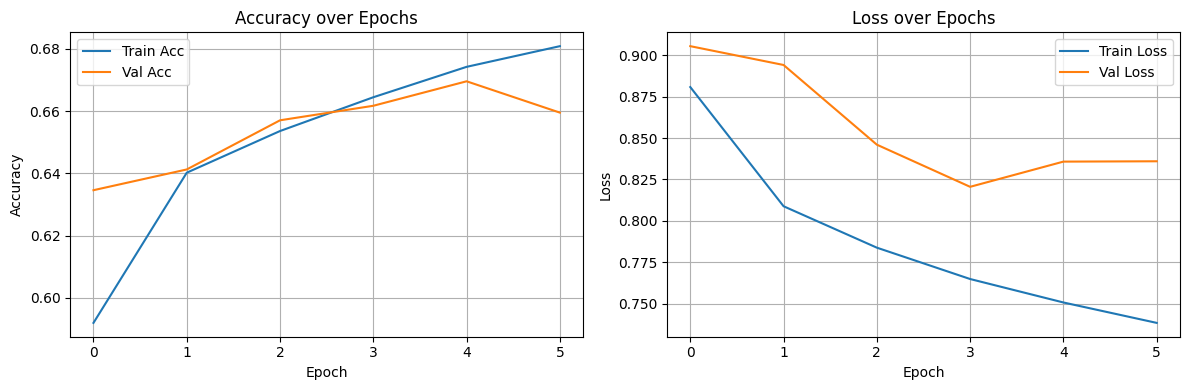

5746/5746 ━━━━━━━━━━━━━━━━━━━━ 109s 19ms/step
5746/5746 ━━━━━━━━━━━━━━━━━━━━ 111s 19ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step


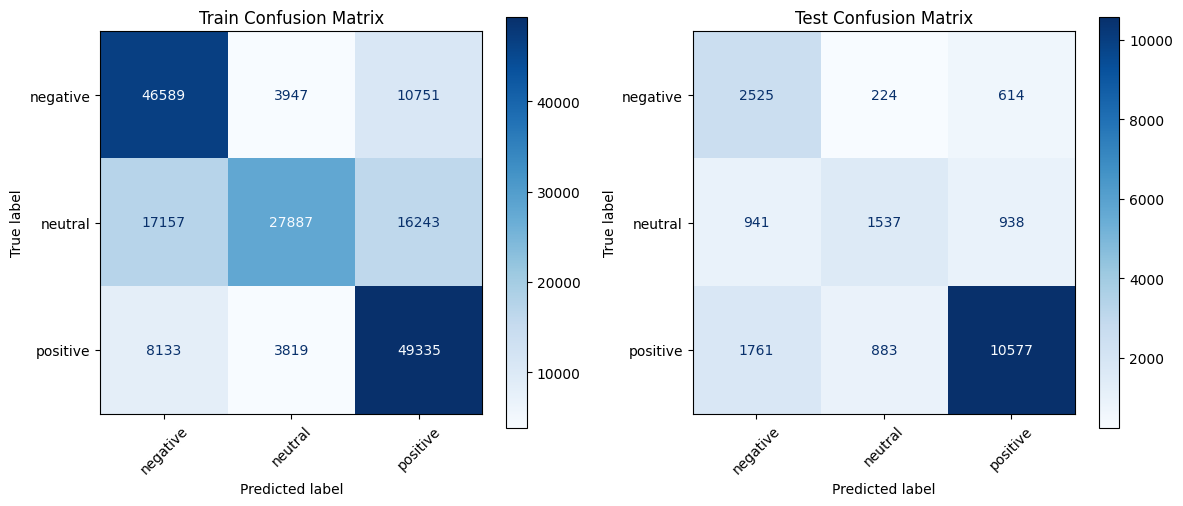


Classification Report - Train:

              precision    recall  f1-score   support

    negative       0.65      0.76      0.70     61287
     neutral       0.78      0.46      0.58     61287
    positive       0.65      0.80      0.72     61287

    accuracy                           0.67    183861
   macro avg       0.69      0.67      0.66    183861
weighted avg       0.69      0.67      0.66    183861


Classification Report - Test:

              precision    recall  f1-score   support

    negative       0.48      0.75      0.59      3363
     neutral       0.58      0.45      0.51      3416
    positive       0.87      0.80      0.83     13221

    accuracy                           0.73     20000
   macro avg       0.65      0.67      0.64     20000
weighted avg       0.76      0.73      0.74     20000


F1 Score Comparison:
Metric     | Train    | Test    
------------------------------
Macro      | 0.6640  | 0.6432
Micro      | 0.6734  | 0.7319
Weighted   | 0.6640  | 0.73

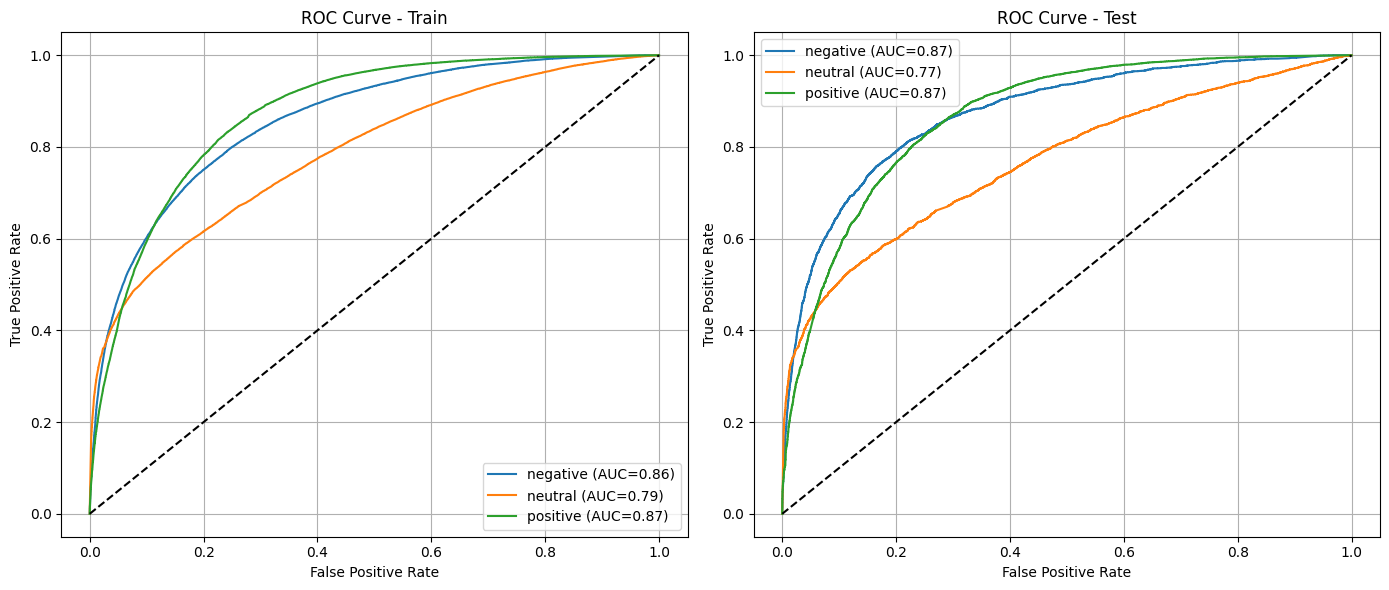

In [193]:
evaluate_model_classification(
    model=model,
    X_train=X_train_tok, y_train=y_train_enc,
    X_test=X_test_tok, y_test=y_test_enc,
    label_encoder=le
)

### Observation



#### Summary 



## **Iteration #2**



From the above Iteration 1 , The class imbalance still persists as the model gives low wightage and is not learning much from the neutral class. 


### Re applying class weights

In [195]:
# Compute initial balanced class weights
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(y_train_enc),
                                     y=y_train_enc)

# Boost weight of neutral class manually
boost_factor = 1.4   # Tune this (e.g., 1.2 to 2.0)
class_weights[1] *= boost_factor  # index 1 is for neutral class

# Convert to dictionary for Keras
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("Adjusted Class Weights:", class_weight_dict)


Adjusted Class Weights: {0: 1.0, 1: 1.4, 2: 1.0}


In [197]:
# Define the Transformer Block with Relative Causal Attention and Pre-Norm
class CausalTransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, max_len):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.max_len = max_len
        self.head_dim = embed_dim // num_heads

        # Linear projections
        self.q_proj = layers.Dense(embed_dim)
        self.k_proj = layers.Dense(embed_dim)
        self.v_proj = layers.Dense(embed_dim)
        self.out_proj = layers.Dense(embed_dim)

        # Relative Position Embedding
        self.rel_pos_emb = RelativePositionEmbedding(max_len, self.head_dim)

        # Feedforward network with GELU
        self.ffn = keras.Sequential([
            layers.Dense(self.ff_dim, activation="gelu"),
            layers.Dense(self.embed_dim),
        ])

        # LayerNorm (applied before attention & FFN)
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(0.4)
        self.dropout2 = layers.Dropout(0.4)

    def call(self, inputs, tokens=None, training=None):
        batch_size, seq_len, _ = tf.shape(inputs)[0], tf.shape(inputs)[1], tf.shape(inputs)[2]

        # --- Attention block ---
        x_norm = self.layernorm1(inputs)  # pre-norm before attention
        q = self.q_proj(x_norm)
        k = self.k_proj(x_norm)
        v = self.v_proj(x_norm)

        q = tf.reshape(q, (batch_size, seq_len, self.num_heads, self.head_dim))
        k = tf.reshape(k, (batch_size, seq_len, self.num_heads, self.head_dim))
        v = tf.reshape(v, (batch_size, seq_len, self.num_heads, self.head_dim))

        q = tf.transpose(q, perm=[0, 2, 1, 3])
        k = tf.transpose(k, perm=[0, 2, 1, 3])
        v = tf.transpose(v, perm=[0, 2, 1, 3])

        rel_pos = self.rel_pos_emb(seq_len, seq_len)
        rel_pos = tf.transpose(rel_pos, [2, 0, 1])

        attn_logits = tf.einsum('bhqd,bhkd->bhqk', q, k)
        rel_logits = tf.einsum('bhqd,dqk->bhqk', q, rel_pos)
        attn_logits += rel_logits

        causal_mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
        causal_mask = tf.reshape(causal_mask, (1, 1, seq_len, seq_len))
        attn_logits = tf.where(causal_mask == 0, -1e9, attn_logits)

        attention_weights = tf.nn.softmax(attn_logits, axis=-1)
        attn_output = tf.matmul(attention_weights, v)
        attn_output = tf.transpose(attn_output, perm=[0, 2, 1, 3])
        attn_output = tf.reshape(attn_output, (batch_size, seq_len, self.embed_dim))

        attention_out = self.out_proj(attn_output)
        x = inputs + self.dropout1(attention_out, training=training)  # Residual connection

        # --- FFN block ---
        x_ffn = self.layernorm2(x)  # pre-norm before FFN
        ffn_out = self.ffn(x_ffn)
        return x + self.dropout2(ffn_out, training=training)  # Final residual


In [198]:
def build_model(max_len, vocab_size, embedding_matrix, num_classes):
    inputs = keras.Input(shape=(max_len,), dtype=tf.int32)

    x = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_matrix.shape[1],
        weights=[embedding_matrix],
        trainable=False,
        mask_zero=False,
    )(inputs)

    # Two transformer blocks
    x = CausalTransformerBlock(embed_dim=embedding_matrix.shape[1], num_heads=3, ff_dim=512, max_len=max_len)(x, inputs)
    x = layers.Dropout(0.4)(x)
    x = CausalTransformerBlock(embed_dim=embedding_matrix.shape[1], num_heads=3, ff_dim=300, max_len=max_len)(x, inputs)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    return model

In [199]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=10000,
    decay_rate=0.95
)

In [200]:
model = build_model(
    max_len=MAX_LEN,
    vocab_size=embedding_matrix.shape[0],
    embedding_matrix=embedding_matrix,
    num_classes=len(le.classes_)
)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)
model.summary()

Model: "functional_55"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_54 (InputLayer)   │ (None, 50)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_18 (Embedding)      │ (None, 50, 300)           │       3,000,600 │ input_layer_54[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ causal_transformer_block_31   │ (None, 50, 300)           │         680,312 │ embedding_18[0][0],        │
│ (CausalTransformerBlock)      │                           │                 │ input_layer_54[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_117 (Dropout)         │ (None, 50, 300)           │               0 │ causal_transformer_block_… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ causal_transformer_block_32   │ (None, 50, 300)           │         552,900 │ dropout_117[0][0],         │
│ (CausalTransformerBlock)      │                           │                 │ input_layer_54[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d_23   │ (None, 300)               │               0 │ causal_transformer_block_… │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_120 (Dropout)         │ (None, 300)               │               0 │ global_average_pooling1d_… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_160 (Dense)             │ (None, 128)               │          38,528 │ dropout_120[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_121 (Dropout)         │ (None, 128)               │               0 │ dense_160[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_161 (Dense)             │ (None, 3)                 │             387 │ dropout_121[0][0]          │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 4,272,727 (16.30 MB)

 Trainable params: 1,272,127 (4.85 MB)

 Non-trainable params: 3,000,600 (11.45 MB)

In [201]:
model.fit(
    X_train_tok,
    y_train_enc,
    validation_data=(X_val_tok, y_val_enc),
    batch_size=64,
    epochs=8,
    callbacks=callbacks
)

Epoch 1/8
2873/2873 ━━━━━━━━━━━━━━━━━━━━ 474s 164ms/step - accuracy: 0.5912 - loss: 0.9047 - val_accuracy: 0.6020 - val_loss: 0.8736
Epoch 2/8
2873/2873 ━━━━━━━━━━━━━━━━━━━━ 472s 164ms/step - accuracy: 0.6428 - loss: 0.8151 - val_accuracy: 0.6537 - val_loss: 0.7948
Epoch 3/8
2873/2873 ━━━━━━━━━━━━━━━━━━━━ 499s 174ms/step - accuracy: 0.6507 - loss: 0.7992 - val_accuracy: 0.6515 - val_loss: 0.8029
Epoch 4/8
2873/2873 ━━━━━━━━━━━━━━━━━━━━ 504s 175ms/step - accuracy: 0.6542 - loss: 0.7944 - val_accuracy: 0.6529 - val_loss: 0.7971



Accuracy:
Train Accuracy: 0.6561
Test Accuracy:  0.7024


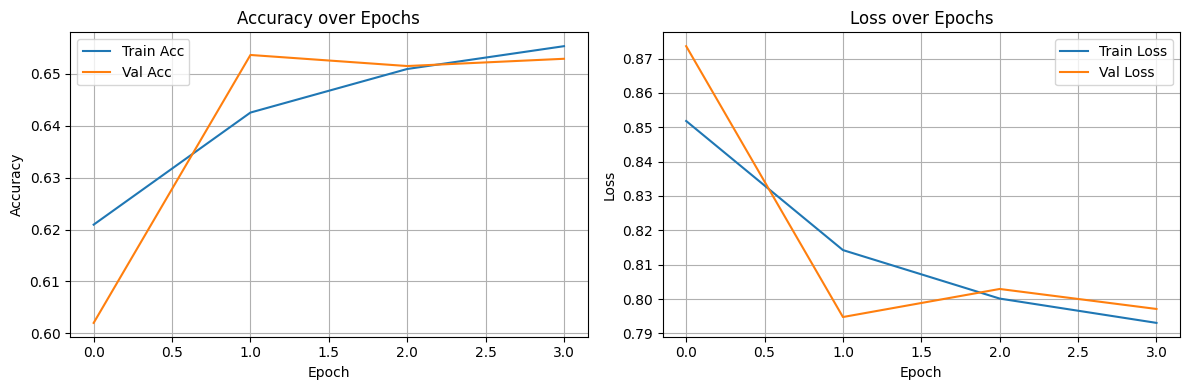

4605/5746 ━━━━━━━━━━━━━━━━━━━━ 29s 26ms/step

In [ ]:
evaluate_model_classification(
    model=model,
    X_train=X_train_tok, y_train=y_train_enc,
    X_test=X_test_tok, y_test=y_test_enc,
    label_encoder=le
)

# **Observations and Summary**

## **Model Interpretability**

In [ ]:
class_names = ['Negative', 'Neutral', 'Positive']

# Your tokenizer (already trained on train+val+test text)
def predict_prob(texts):
    # Convert list of raw texts → padded sequences
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(sequences, maxlen=max_len)
    
    # Get softmax probabilities from the model
    return model.predict(padded)

In [ ]:
explainer = LimeTextExplainer(class_names=class_names)

# Choose a sample raw tweet/text
sample_idx = 10  # Any index of interest
sample_text = raw_texts_test[sample_idx]

exp = explainer.explain_instance(sample_text, predict_prob, num_features=10, top_labels=1)
exp.show_in_notebook(text=True)


# Visualize explanation
exp.show_in_notebook(text=True)


LIME shows that the model predicted the input as Strong_Pos (41%) based on key words like freedom, city, million, and manager. While the prediction was dominant, the confidence was distributed — suggesting borderline sentiment. The highlighted tokens provide insight into how the model interprets input features, and help validate whether its focus aligns with human intuition.

## Additional Steps to improve model performance 

**Model Architechture enhancements** : 

Add Attention Layer which will Help the model focus on important words in the sentence.

Stack BiLSTM Layers to Captures deeper and more complex sequential dependencies.

**Training & Regularization Techniques**:

Apply Learning Rate Scheduling which Dynamically reduces the learning rate when validation loss plateaus.

Use Focal Loss (instead of cross-entropy) to Addresses class imbalance by focusing more on harder examples.

Fine-Tune Class Weights to Manually adjust or recompute based on performance gaps between classes